In [1]:
import os
import clip
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = "cuda"

# --- Load CLIP ---
print("Loading CLIP model...")
model, preprocess = clip.load("ViT-L/14", device=device)
model.eval()
print(f"Using: {torch.cuda.get_device_name(0)}")

Loading CLIP model...
Using: NVIDIA RTX A6000


In [2]:
import os

base_path = "dataset/bffhq/1pct"

class_0_path = os.path.join(base_path, "0")
class_1_path = os.path.join(base_path, "1")

len_0 = len(os.listdir(class_0_path))
len_1 = len(os.listdir(class_1_path))

print("Length of 1pct/0:", len_0)
print("Length of 1pct/1:", len_1)

Length of 1pct/0: 9600
Length of 1pct/1: 9600


In [2]:
import torch
import numpy as np

# Load
train_embs  = torch.load("1pct/embeddings/train_embs.pt").float()
test_embs   = torch.load("1pct/embeddings/test_embs.pt").float()
valid_embs  = torch.load("1pct/embeddings/valid_embs.pt").float()
young_0_embs=torch.load("1pct/embeddings/young_0_embs.pt").float()
old_1_embs=torch.load("1pct/embeddings/old_1_embs.pt").float()


young_0_age=np.load("1pct/embeddings/young_0_age.npy")
young_0_gender=np.load("1pct/embeddings/young_0_gender.npy")
old_1_age=np.load("1pct/embeddings/old_1_age.npy")
old_1_gender=np.load("1pct/embeddings/old_1_gender.npy")
train_age     = np.load("1pct/embeddings/train_age.npy")
train_gender  = np.load("1pct/embeddings/train_gender.npy")
test_age      = np.load("1pct/embeddings/test_age.npy")
test_gender   = np.load("1pct/embeddings/test_gender.npy")
valid_age     = np.load("1pct/embeddings/valid_age.npy")
valid_gender  = np.load("1pct/embeddings/valid_gender.npy")

In [15]:
# --- Bias check ---
print("\n--- Bias check ---")
for split, age_l, gen_l in [
    ("test",     test_age,     test_gender),
    ("valid",    valid_age,    valid_gender),
    ("train",    train_age,    train_gender),
    # ("align",    align_age,    align_gender),
    # ("conflict", conflict_age, conflict_gender)
     ("young",    young_0_age,    young_0_gender),
    ("old", old_1_age, old_1_gender)
]:
    print(f"\n{split} (n={len(age_l)}):")
    for age, name in [(0, "young"), (1, "old")]:
        mask = age_l == age
        if mask.sum() == 0:
            continue
        male_pct = (gen_l[mask] == 1).mean() * 100
        print(f"  {name}: {male_pct:.1f}% male, {100-male_pct:.1f}% female  (n={mask.sum()})")


--- Bias check ---

test (n=1000):
  young: 50.0% male, 50.0% female  (n=500)
  old: 50.0% male, 50.0% female  (n=500)

valid (n=1000):
  young: 0.0% male, 100.0% female  (n=500)
  old: 100.0% male, 0.0% female  (n=500)

train (n=19200):
  young: 1.0% male, 99.0% female  (n=9600)
  old: 99.0% male, 1.0% female  (n=9600)

young (n=9600):
  young: 1.0% male, 99.0% female  (n=9600)

old (n=9600):
  old: 99.0% male, 1.0% female  (n=9600)


In [16]:
print(train_embs.shape)
print(test_embs.shape)
print(valid_embs.shape)
# print(align_embs.shape)
# print(conflict_embs.shape)
print(young_0_embs.shape)
print(old_1_embs.shape)

torch.Size([19200, 768])
torch.Size([1000, 768])
torch.Size([1000, 768])
torch.Size([9600, 768])
torch.Size([9600, 768])


# Debiasing Embeddings

## Similarity Threshold = 0.8

In [7]:
import time

# Load age-based embeddings

old_embs   = old_1_embs   # all old (male+female)
young_embs = young_0_embs   # all young (male+female)

print(f"old:   {old_embs.shape}")
print(f"young: {young_embs.shape}")

# Normalize
old_norm   = old_embs   / old_embs.norm(dim=-1, keepdim=True)
young_norm = young_embs / young_embs.norm(dim=-1, keepdim=True)

start=time.time()
# Similarity matrix old↔young (9600 x 9600)
print("Computing similarity matrix...")
sim_matrix = old_norm @ young_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.80  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end=time.time()
print((end-start)/60,"minutes")

old:   torch.Size([9600, 768])
young: torch.Size([9600, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([9600, 9600])
mean=0.555  max=0.938  min=0.102

Pairs with sim > 0.8: 106127
sim range: 0.800 - 0.938
mean sim of selected pairs: 0.818
0.009833184878031413 minutes


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("1pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (old↔young, sim>0.8): {n_pairs}")
neg_e1      = old_embs[old_idx]
neg_e2      = young_embs[young_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) — no gender labels ---
n_pos_each = n_pairs // 2

# young↔young
ym_idx1      = torch.randint(0, len(young_embs), (n_pos_each,))
ym_idx2      = torch.randint(0, len(young_embs), (n_pos_each,))
young_pos_e1 = young_embs[ym_idx1]
young_pos_e2 = young_embs[ym_idx2]

# old↔old
om_idx1    = torch.randint(0, len(old_embs), (n_pos_each,))
om_idx2    = torch.randint(0, len(old_embs), (n_pos_each,))
old_pos_e1 = old_embs[om_idx1]
old_pos_e2 = old_embs[om_idx2]

pos_e1      = torch.cat([young_pos_e1, old_pos_e1])
pos_e2      = torch.cat([young_pos_e2, old_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (old↔young):             {(all_labels==0).sum()}")
print(f"  pull (young↔young + old↔old): {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(young_embs[:1000].to(device))
    p4 = model_head(young_embs[1000:2000].to(device))
    p5 = model_head(old_embs[:1000].to(device))
    p6 = model_head(old_embs[1000:2000].to(device))
print(f"Before training:")
print(f"  push_sim(old↔young):   {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(young↔young): {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(old↔old):     {F.cosine_similarity(p5,p6).mean():.3f}")

start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(young_embs[:1000].to(device))
            p4 = model_head(young_embs[1000:2000].to(device))
            p5 = model_head(old_embs[:1000].to(device))
            p6 = model_head(old_embs[1000:2000].to(device))
            push_sim   = F.cosine_similarity(p1, p2).mean().item()
            pull_young = F.cosine_similarity(p3, p4).mean().item()
            pull_old   = F.cosine_similarity(p5, p6).mean().item()
            w_diff     = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_young={pull_young:.3f}  pull_old={pull_old:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "1pct/push_pull/Projection_heads/projection_head_push_pull(0.8).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (old↔young, sim>0.8): 106127

Total pairs: 212253
  push (old↔young):             106127
  pull (young↔young + old↔old): 106126
Before training:
  push_sim(old↔young):   0.818
  pull_sim(young↔young): 0.687
  pull_sim(old↔old):     0.607

Training...
  epoch   0  loss=0.0768  push_sim=0.066  pull_young=0.863  pull_old=0.869  W_diff=0.00843
  epoch  10  loss=0.0021  push_sim=0.070  pull_young=0.912  pull_old=0.902  W_diff=0.00826
  epoch  20  loss=0.0008  push_sim=0.124  pull_young=0.926  pull_old=0.922  W_diff=0.00660
  epoch  30  loss=0.0003  push_sim=0.061  pull_young=0.935  pull_old=0.934  W_diff=0.00538
  epoch  40  loss=0.0001  push_sim=0.053  pull_young=0.940  pull_old=0.937  W_diff=0.00475
Done!
21.0 minutes


In [19]:
model_head.eval()
with torch.no_grad():
    # Project all embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()

    # Normalize
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    old_norm        = old_embs   / old_embs.norm(dim=-1, keepdim=True)
    young_norm      = young_embs / young_embs.norm(dim=-1, keepdim=True)

    # Push: old↔young similarity
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before = old_norm      @ young_norm.T

    # Pull: within same age group
    # young↔young
    sim_yy_before = young_norm      @ young_norm.T
    sim_yy_after  = young_proj_norm @ young_proj_norm.T
    # old↔old
    sim_oo_before = old_norm      @ old_norm.T
    sim_oo_after  = old_proj_norm @ old_proj_norm.T

    # Exclude diagonal (self similarity = 1)
    mask = ~torch.eye(len(old_embs), dtype=bool)
    mask_y = ~torch.eye(len(young_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (old↔young) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.8: {(sim_before_flat>0.8).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.8: {(sim_after_flat>0.8).sum()}")

print("\nPULL effect (young↔young) — want higher:")
print(f"  BEFORE: mean={sim_yy_before[mask_y].mean():.3f}  "
      f"min={sim_yy_before[mask_y].min():.3f}")
print(f"  AFTER:  mean={sim_yy_after[mask_y].mean():.3f}  "
      f"min={sim_yy_after[mask_y].min():.3f}")

print("\nPULL effect (old↔old) — want higher:")
print(f"  BEFORE: mean={sim_oo_before[mask].mean():.3f}  "
      f"min={sim_oo_before[mask].min():.3f}")
print(f"  AFTER:  mean={sim_oo_after[mask].mean():.3f}  "
      f"min={sim_oo_after[mask].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (old↔young) — want lower:
  BEFORE: mean=0.555  max=0.938  >0.8: 106127
  AFTER:  mean=0.178  max=0.957  >0.8: 7937

PULL effect (young↔young) — want higher:
  BEFORE: mean=0.686  min=0.182
  AFTER:  mean=0.938  min=0.373

PULL effect (old↔old) — want higher:
  BEFORE: mean=0.606  min=0.157
  AFTER:  mean=0.938  min=0.204
W_diff from identity: 0.00462


In [20]:
import os
os.makedirs("1pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "1pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
torch.save(test_proj,  "1pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
torch.save(valid_proj, "1pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")
print("Saved!")

Saved!


In [21]:
train_proj=torch.load("1pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
test_proj=torch.load("1pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
valid_proj=torch.load("1pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")

In [22]:
print(f"train_proj: {train_proj.shape}")  # should be (19200, 768)
print(f"test_proj:  {test_proj.shape}")   # should be (1000, 768)
print(f"valid_proj: {valid_proj.shape}")  # should be (1000, 768)

train_proj: torch.Size([19200, 768])
test_proj:  torch.Size([1000, 768])
valid_proj: torch.Size([1000, 768])


In [23]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 92.0%
  young female  : 100.0%
  young male    : 86.4%
  old female  : 82.8%
  old male    : 98.8%
  worst: 82.8%  best: 100.0%  gap: 17.2%

  DEBIASED (linear push)
Overall accuracy: 91.3%
  young female  : 100.0%
  young male    : 83.6%
  old female  : 82.4%
  old male    : 99.2%
  worst: 82.4%  best: 100.0%  gap: 17.6%


Running t-SNE for train (proj) (19200 points)...
Running t-SNE for test (proj) (1000 points)...
Running t-SNE for valid (proj) (1000 points)...
Running t-SNE for old (proj) (9600 points)...
Running t-SNE for young (proj) (9600 points)...
Saved!


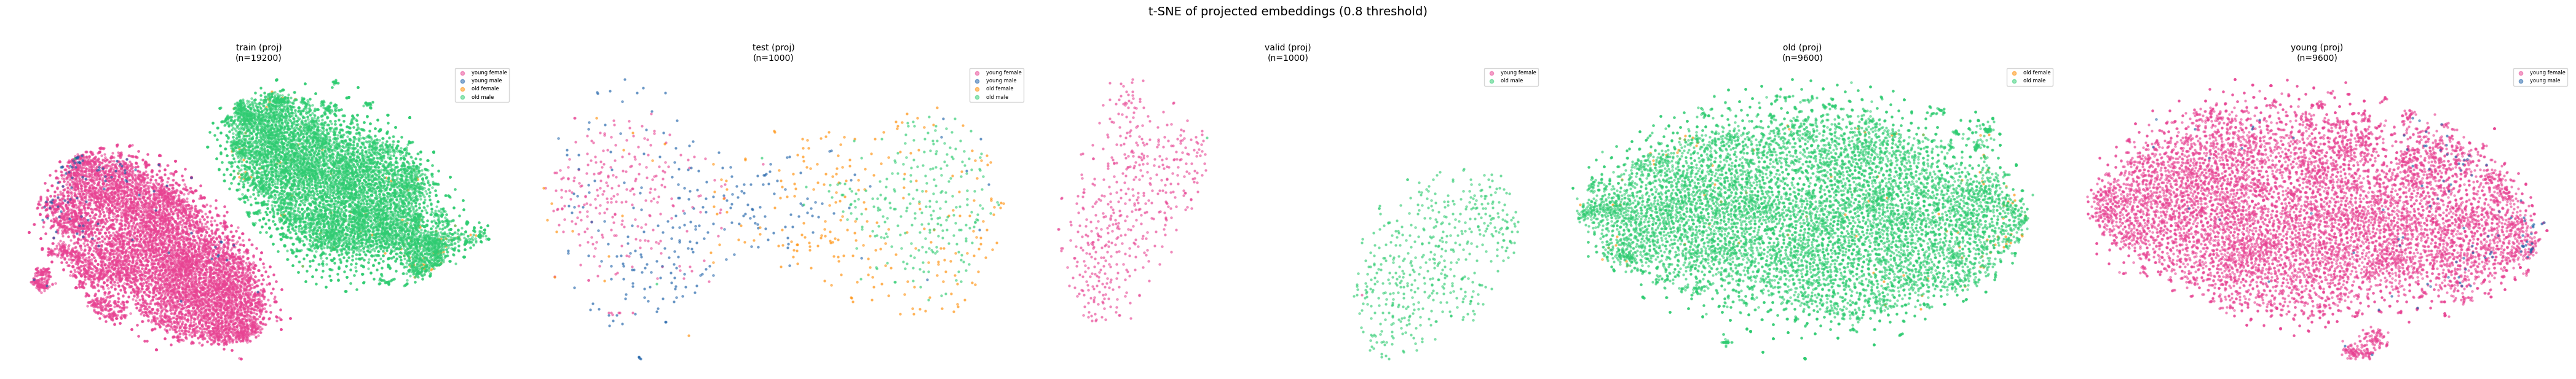

In [24]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("1pct/push_pull/tsne", exist_ok=True)

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)
    
device     = "cuda"
model_head  = LinearDebias().to(device)  
model_head.load_state_dict(torch.load("1pct/push_pull/Projection_heads/projection_head_push_pull(0.8).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",    project(train_embs),    train_age,    train_gender),
    ("test (proj)",     project(test_embs),      test_age,     test_gender),
    ("valid (proj)",    project(valid_embs),     valid_age,    valid_gender),
    # ("align (proj)",    project(align_embs),     align_age,    align_gender),
    # ("conflict (proj)", project(conflict_embs),  conflict_age, conflict_gender),
    ("old (proj)",      project(old_1_embs),       old_1_age,    old_1_gender),
    ("young (proj)",    project(young_0_embs),     young_0_age,  young_0_gender),
]

# 5 splits → 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(42, 6))

for ax, (name, embs, age, gender) in zip(axes, splits):
    group = age * 2 + gender
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

plt.suptitle("t-SNE of projected embeddings (0.8 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("1pct/push_pull/tsne/tsne_projected_all_splits(0.8).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [25]:
model_head.eval()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()   # original
    proj = project(embs_tensor)        # projected

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # # Save original
    # plt.figure(figsize=(7, 6))
    # for g, gname in group_names.items():
    #     mask = group == g
    #     if mask.sum() == 0: continue
    #     plt.scatter(orig_2d[mask, 0], orig_2d[mask, 1],
    #                 c=colors[g], label=gname, s=5, alpha=0.6)
    # plt.title(f"{name} — original (n={n})", fontsize=13)
    # plt.legend(fontsize=9, markerscale=2)
    # plt.axis("off")
    # plt.tight_layout()
    # plt.savefig(f"1pct/tsne/tsne_{name}_original.png", dpi=150, bbox_inches="tight")
    # plt.close()
    # print(f"Saved tsne_{name}_original.png")

    # Save projected
    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0: continue
        plt.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                    c=colors[g], label=gname, s=5, alpha=0.6)
    plt.title(f"{name} — projected (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"1pct/push_pull/tsne/tsne_{name}_projected(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_projected(0.8).png")

t-SNE original  train (19200 points)...
t-SNE projected train (19200 points)...
Saved tsne_train_projected(0.8).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_projected(0.8).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_projected(0.8).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_projected(0.8).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_projected(0.8).png


In [26]:
model_head.eval()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0: continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"1pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.8).png")

t-SNE original  train (19200 points)...
t-SNE projected train (19200 points)...
Saved tsne_train_orig_vs_proj(0.8).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_orig_vs_proj(0.8).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_orig_vs_proj(0.8).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_orig_vs_proj(0.8).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_orig_vs_proj(0.8).png


## Similarity Threshold = 0.75

In [8]:
import time

# Find pairs with similarity > threshold k
k_threshold = 0.75  # only push very similar pairs

start = time.time()

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print((end-start)/60,"minutes")


Pairs with sim > 0.75: 1160714
sim range: 0.750 - 0.938
mean sim of selected pairs: 0.772
0.003749704360961914 minutes


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("1pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (old↔young, sim>0.75): {n_pairs}")
neg_e1      = old_embs[old_idx]
neg_e2      = young_embs[young_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) — no gender labels ---
n_pos_each = n_pairs // 2

# young↔young
ym_idx1      = torch.randint(0, len(young_embs), (n_pos_each,))
ym_idx2      = torch.randint(0, len(young_embs), (n_pos_each,))
young_pos_e1 = young_embs[ym_idx1]
young_pos_e2 = young_embs[ym_idx2]

# old↔old
om_idx1    = torch.randint(0, len(old_embs), (n_pos_each,))
om_idx2    = torch.randint(0, len(old_embs), (n_pos_each,))
old_pos_e1 = old_embs[om_idx1]
old_pos_e2 = old_embs[om_idx2]

pos_e1      = torch.cat([young_pos_e1, old_pos_e1])
pos_e2      = torch.cat([young_pos_e2, old_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (old↔young):             {(all_labels==0).sum()}")
print(f"  pull (young↔young + old↔old): {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(young_embs[:1000].to(device))
    p4 = model_head(young_embs[1000:2000].to(device))
    p5 = model_head(old_embs[:1000].to(device))
    p6 = model_head(old_embs[1000:2000].to(device))
print(f"Before training:")
print(f"  push_sim(old↔young):   {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(young↔young): {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(old↔old):     {F.cosine_similarity(p5,p6).mean():.3f}")

start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(young_embs[:1000].to(device))
            p4 = model_head(young_embs[1000:2000].to(device))
            p5 = model_head(old_embs[:1000].to(device))
            p6 = model_head(old_embs[1000:2000].to(device))
            push_sim   = F.cosine_similarity(p1, p2).mean().item()
            pull_young = F.cosine_similarity(p3, p4).mean().item()
            pull_old   = F.cosine_similarity(p5, p6).mean().item()
            w_diff     = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_young={pull_young:.3f}  pull_old={pull_old:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "1pct/push_pull/Projection_heads/projection_head_push_pull(0.75).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (old↔young, sim>0.75): 1160714

Total pairs: 2321428
  push (old↔young):             1160714
  pull (young↔young + old↔old): 1160714
Before training:
  push_sim(old↔young):   0.777
  pull_sim(young↔young): 0.687
  pull_sim(old↔old):     0.607

Training...
  epoch   0  loss=0.0093  push_sim=-0.035  pull_young=0.916  pull_old=0.909  W_diff=0.00786
  epoch  10  loss=0.0002  push_sim=-0.181  pull_young=0.972  pull_old=0.967  W_diff=0.00263
  epoch  20  loss=0.0001  push_sim=-0.198  pull_young=0.970  pull_old=0.970  W_diff=0.00226


In [ ]:
model_head.eval()
with torch.no_grad():
    # Project all embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()

    # Normalize
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    old_norm        = old_embs   / old_embs.norm(dim=-1, keepdim=True)
    young_norm      = young_embs / young_embs.norm(dim=-1, keepdim=True)

    # Push: old↔young similarity
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before = old_norm      @ young_norm.T

    # Pull: within same age group
    # young↔young
    sim_yy_before = young_norm      @ young_norm.T
    sim_yy_after  = young_proj_norm @ young_proj_norm.T
    # old↔old
    sim_oo_before = old_norm      @ old_norm.T
    sim_oo_after  = old_proj_norm @ old_proj_norm.T

    # Exclude diagonal (self similarity = 1)
    mask = ~torch.eye(len(old_embs), dtype=bool)
    mask_y = ~torch.eye(len(young_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (old↔young) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.75: {(sim_before_flat>0.75).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.75: {(sim_after_flat>0.75).sum()}")

print("\nPULL effect (young↔young) — want higher:")
print(f"  BEFORE: mean={sim_yy_before[mask_y].mean():.3f}  "
      f"min={sim_yy_before[mask_y].min():.3f}")
print(f"  AFTER:  mean={sim_yy_after[mask_y].mean():.3f}  "
      f"min={sim_yy_after[mask_y].min():.3f}")

print("\nPULL effect (old↔old) — want higher:")
print(f"  BEFORE: mean={sim_oo_before[mask].mean():.3f}  "
      f"min={sim_oo_before[mask].min():.3f}")
print(f"  AFTER:  mean={sim_oo_after[mask].mean():.3f}  "
      f"min={sim_oo_after[mask].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (old↔young) — want lower:
  BEFORE: mean=0.555  max=0.933  >0.75: 1121951
  AFTER:  mean=-0.137  max=0.665  >0.75: 0

PULL effect (young↔young) — want higher:
  BEFORE: mean=0.688  min=0.188
  AFTER:  mean=0.984  min=0.699

PULL effect (old↔old) — want higher:
  BEFORE: mean=0.606  min=0.157
  AFTER:  mean=0.981  min=0.723
W_diff from identity: 0.00143


In [ ]:
import os
os.makedirs("1pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "1pct/push_pull/embeddings/train_proj(0.75).pt")
torch.save(test_proj,  "1pct/push_pull/embeddings/test_proj(0.75).pt")
torch.save(valid_proj, "1pct/push_pull/embeddings/valid_proj(0.75).pt")
print("Saved!")

Saved!


In [ ]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("1pct/push_pull/embeddings/train_proj(0.75).pt")
test_proj=torch.load("1pct/push_pull/embeddings/test_proj(0.75).pt")
valid_proj=torch.load("1pct/push_pull/embeddings/valid_proj(0.75).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3247600/2746834933.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.75).pt")
/tmp/ipykernel


  BASELINE
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 85.6%
  old female  : 78.0%
  old male    : 99.6%
  worst: 78.0%  best: 100.0%  gap: 22.0%

  DEBIASED (linear push)
Overall accuracy: 90.0%
  young female  : 99.6%
  young male    : 84.4%
  old female  : 76.4%
  old male    : 99.6%
  worst: 76.4%  best: 99.6%  gap: 23.2%


## Similarity Threshold = 0.85

In [ ]:
# Find pairs with similarity > threshold k
k_threshold = 0.85  # only push very similar pairs

start = time.time()

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print((end-start)/60,"minutes")


Pairs with sim > 0.85: 3466
sim range: 0.850 - 0.933
mean sim of selected pairs: 0.864
0.0031081835428873696 minutes


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("1pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (old↔young, sim>0.85): {n_pairs}")
neg_e1      = old_embs[old_idx]
neg_e2      = young_embs[young_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) — no gender labels ---
n_pos_each = n_pairs // 2

# young↔young
ym_idx1      = torch.randint(0, len(young_embs), (n_pos_each,))
ym_idx2      = torch.randint(0, len(young_embs), (n_pos_each,))
young_pos_e1 = young_embs[ym_idx1]
young_pos_e2 = young_embs[ym_idx2]

# old↔old
om_idx1    = torch.randint(0, len(old_embs), (n_pos_each,))
om_idx2    = torch.randint(0, len(old_embs), (n_pos_each,))
old_pos_e1 = old_embs[om_idx1]
old_pos_e2 = old_embs[om_idx2]

pos_e1      = torch.cat([young_pos_e1, old_pos_e1])
pos_e2      = torch.cat([young_pos_e2, old_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (old↔young):             {(all_labels==0).sum()}")
print(f"  pull (young↔young + old↔old): {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(young_embs[:1000].to(device))
    p4 = model_head(young_embs[1000:2000].to(device))
    p5 = model_head(old_embs[:1000].to(device))
    p6 = model_head(old_embs[1000:2000].to(device))
print(f"Before training:")
print(f"  push_sim(old↔young):   {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(young↔young): {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(old↔old):     {F.cosine_similarity(p5,p6).mean():.3f}")

start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(young_embs[:1000].to(device))
            p4 = model_head(young_embs[1000:2000].to(device))
            p5 = model_head(old_embs[:1000].to(device))
            p6 = model_head(old_embs[1000:2000].to(device))
            push_sim   = F.cosine_similarity(p1, p2).mean().item()
            pull_young = F.cosine_similarity(p3, p4).mean().item()
            pull_old   = F.cosine_similarity(p5, p6).mean().item()
            w_diff     = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_young={pull_young:.3f}  pull_old={pull_old:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "1pct/push_pull/Projection_heads/projection_head_push_pull(0.85).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (old↔young, sim>0.85): 3466

Total pairs: 6932
  push (old↔young):             3466
  pull (young↔young + old↔old): 3466
Before training:
  push_sim(old↔young):   0.865
  pull_sim(young↔young): 0.690
  pull_sim(old↔old):     0.609

Training...
  epoch   0  loss=0.4369  push_sim=0.863  pull_young=0.750  pull_old=0.703  W_diff=0.00100
  epoch  10  loss=0.0493  push_sim=0.308  pull_young=0.818  pull_old=0.825  W_diff=0.00670
  epoch  20  loss=0.0238  push_sim=0.221  pull_young=0.844  pull_old=0.851  W_diff=0.00786
  epoch  30  loss=0.0165  push_sim=0.198  pull_young=0.852  pull_old=0.858  W_diff=0.00829
  epoch  40  loss=0.0140  push_sim=0.193  pull_young=0.855  pull_old=0.860  W_diff=0.00844
Done!
0.4 minutes


In [ ]:
model_head.eval()
with torch.no_grad():
    # Project all embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()

    # Normalize
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    old_norm        = old_embs   / old_embs.norm(dim=-1, keepdim=True)
    young_norm      = young_embs / young_embs.norm(dim=-1, keepdim=True)

    # Push: old↔young similarity
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before = old_norm      @ young_norm.T

    # Pull: within same age group
    # young↔young
    sim_yy_before = young_norm      @ young_norm.T
    sim_yy_after  = young_proj_norm @ young_proj_norm.T
    # old↔old
    sim_oo_before = old_norm      @ old_norm.T
    sim_oo_after  = old_proj_norm @ old_proj_norm.T

    # Exclude diagonal (self similarity = 1)
    mask = ~torch.eye(len(old_embs), dtype=bool)
    mask_y = ~torch.eye(len(young_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (old↔young) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.85: {(sim_before_flat>0.85).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.85: {(sim_after_flat>0.85).sum()}")

print("\nPULL effect (young↔young) — want higher:")
print(f"  BEFORE: mean={sim_yy_before[mask_y].mean():.3f}  "
      f"min={sim_yy_before[mask_y].min():.3f}")
print(f"  AFTER:  mean={sim_yy_after[mask_y].mean():.3f}  "
      f"min={sim_yy_after[mask_y].min():.3f}")

print("\nPULL effect (old↔old) — want higher:")
print(f"  BEFORE: mean={sim_oo_before[mask].mean():.3f}  "
      f"min={sim_oo_before[mask].min():.3f}")
print(f"  AFTER:  mean={sim_oo_after[mask].mean():.3f}  "
      f"min={sim_oo_after[mask].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (old↔young) — want lower:
  BEFORE: mean=0.555  max=0.933  >0.85: 3466
  AFTER:  mean=0.192  max=0.928  >0.85: 1032

PULL effect (young↔young) — want higher:
  BEFORE: mean=0.688  min=0.188
  AFTER:  mean=0.856  min=-0.132

PULL effect (old↔old) — want higher:
  BEFORE: mean=0.606  min=0.157
  AFTER:  mean=0.860  min=-0.049
W_diff from identity: 0.00846


In [ ]:
import os
os.makedirs("1pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "1pct/push_pull/embeddings/train_proj(0.85).pt")
torch.save(test_proj,  "1pct/push_pull/embeddings/test_proj(0.85).pt")
torch.save(valid_proj, "1pct/push_pull/embeddings/valid_proj(0.85).pt")
print("Saved!")

Saved!


In [ ]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("1pct/push_pull/embeddings/train_proj(0.85).pt")
test_proj=torch.load("1pct/push_pull/embeddings/test_proj(0.85).pt")
valid_proj=torch.load("1pct/push_pull/embeddings/valid_proj(0.85).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3247600/3350581903.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj(0.85).pt")
/tmp/ipykernel


  BASELINE
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 85.6%
  old female  : 78.0%
  old male    : 99.6%
  worst: 78.0%  best: 100.0%  gap: 22.0%

  DEBIASED (linear push)
Overall accuracy: 92.5%
  young female  : 100.0%
  young male    : 87.2%
  old female  : 83.6%
  old male    : 99.2%
  worst: 83.6%  best: 100.0%  gap: 16.4%


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]


for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0: continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"1pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.85).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.85).png")

t-SNE original  train (19200 points)...


t-SNE projected train (19200 points)...
Saved tsne_train_orig_vs_proj(0.85).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_orig_vs_proj(0.85).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_orig_vs_proj(0.85).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_orig_vs_proj(0.85).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_orig_vs_proj(0.85).png
